# Mini-Challenge 2: Sentiment Analysis

This notebook consolidates the entire project, keeping helper files inline except `models.py` which is needed externally for Apple Silicon performance optimization.

In [ ]:
import os
from pathlib import Path
from typing import Dict, List

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["MPLCONFIGDIR"] = os.path.abspath(".matplotlib")
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import openai
import pandas as pd
import seaborn as sns
import umap
from datasets import load_dataset
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from transformers import logging as transformers_logging

from models import SentimentClassifier, evaluate_classifier, train_classifier

load_dotenv()
transformers_logging.set_verbosity_error()

In [2]:
def _find_local_phrasebank_dir() -> Path:
    """Locate a locally cached Financial PhraseBank directory if HF loading is unavailable."""
    candidate_roots = [
        Path.cwd() / "FinancialPhraseBank-v1.0",
        Path.home() / ".cache" / "huggingface" / "datasets" / "downloads" / "extracted",
    ]

    for root in candidate_roots:
        if not root.exists():
            continue

        if root.name == "FinancialPhraseBank-v1.0" and (root / "Sentences_AllAgree.txt").exists():
            return root

        for candidate in root.rglob("FinancialPhraseBank-v1.0"):
            if (candidate / "Sentences_AllAgree.txt").exists():
                return candidate

    raise FileNotFoundError(
        "Could not find a local FinancialPhraseBank-v1.0 directory. "
        "Download the dataset once with Hugging Face or place the raw files locally."
    )


def _load_phrasebank_subset(
    config_name: str,
    dataset_name: str = "takala/financial_phrasebank",
) -> pd.DataFrame:
    """Load one agreement subset, preferring Hugging Face and falling back to local raw files."""
    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    filename_map = {
        "sentences_allagree": "Sentences_AllAgree.txt",
        "sentences_75agree": "Sentences_75Agree.txt",
        "sentences_66agree": "Sentences_66Agree.txt",
        "sentences_50agree": "Sentences_50Agree.txt",
    }

    try:
        dataset = load_dataset(dataset_name, config_name, split="train")
        df = dataset.to_pandas()[["sentence", "label"]].copy()
        if df["label"].dtype == object:
            df["label"] = df["label"].map(label_map)
    except Exception as exc:
        print(f"Falling back to local raw files for {config_name}: {exc}")
        dataset_dir = _find_local_phrasebank_dir()
        rows = []
        with open(dataset_dir / filename_map[config_name], encoding="iso-8859-1") as handle:
            for line in handle:
                sentence, label = line.rsplit("@", 1)
                rows.append(
                    {
                        "sentence": sentence,
                        "label": label_map[label.strip()],
                    }
                )
        df = pd.DataFrame(rows)

    df["agreement_subset"] = config_name
    return df


def _deduplicate_sentences(df: pd.DataFrame, subset_name: str) -> pd.DataFrame:
    """Drop duplicate sentences, keeping the first occurrence to preserve agreement priority."""
    duplicate_rows = df[df.duplicated(subset=["sentence"], keep=False)]
    if not duplicate_rows.empty:
        conflicting_duplicates = (
            duplicate_rows.groupby("sentence")["label"].nunique().gt(1).sum()
        )
        deduped = df.drop_duplicates(subset=["sentence"], keep="first").copy()
        removed_rows = len(df) - len(deduped)
        print(
            f"{subset_name}: removed {removed_rows} duplicate rows "
            f"across {duplicate_rows['sentence'].nunique()} duplicated sentences "
            f"({conflicting_duplicates} conflicting-label cases resolved by first occurrence)."
        )
        return deduped.reset_index(drop=True)

    return df.reset_index(drop=True)


def _attach_example_ids(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    result = df.copy().reset_index(drop=True)
    result.index = [f"{prefix}_{idx:05d}" for idx in range(len(result))]
    result.index.name = "example_id"
    return result


def load_agreement_aware_splits(
    dataset_name: str = "takala/financial_phrasebank",
    seed: int = 42,
    test_size: float = 0.2,
    val_size: float = 0.1,
    train_sizes: List[int] = [100, 250, 500, 1000],
) -> Dict[str, pd.DataFrame]:
    """Create agreement-aware Financial PhraseBank splits for clean training and dual testing."""
    if train_sizes != sorted(train_sizes):
        raise ValueError("train_sizes must be sorted in ascending order.")

    max_train_size = max(train_sizes)

    print("Loading Financial PhraseBank agreement subsets...")
    allagree_df = _deduplicate_sentences(
        _load_phrasebank_subset("sentences_allagree", dataset_name),
        subset_name="100% agreement subset",
    )
    allagree_df = _attach_example_ids(allagree_df, prefix="allagree")

    non100_frames = []
    for config_name in ["sentences_75agree", "sentences_66agree", "sentences_50agree"]:
        subset_df = _load_phrasebank_subset(config_name, dataset_name)
        non100_frames.append(subset_df)

    combined_non100_df = pd.concat(non100_frames, ignore_index=True)
    combined_non100_df = combined_non100_df[
        ~combined_non100_df["sentence"].isin(set(allagree_df["sentence"]))
    ].copy()
    combined_non100_df = _deduplicate_sentences(
        combined_non100_df,
        subset_name="Combined non-100% agreement pool",
    )
    combined_non100_df = _attach_example_ids(combined_non100_df, prefix="disagree")

    remaining_allagree_df, test_allagree_df = train_test_split(
        allagree_df,
        test_size=test_size,
        random_state=seed,
        stratify=allagree_df["label"],
    )
    remaining_disagree_df, test_disagree_df = train_test_split(
        combined_non100_df,
        test_size=test_size,
        random_state=seed,
        stratify=combined_non100_df["label"],
    )

    train_hidden_allagree_df, val_allagree_df = train_test_split(
        remaining_allagree_df,
        test_size=val_size,
        random_state=seed,
        stratify=remaining_allagree_df["label"],
    )

    if len(train_hidden_allagree_df) <= max_train_size:
        raise ValueError(
            "Not enough 100%-agreement data left after test/val splits to support "
            f"max training size {max_train_size}."
        )

    shuffled_clean_pool = train_hidden_allagree_df.sample(frac=1, random_state=seed)
    hard_label_train_pool = shuffled_clean_pool.iloc[:max_train_size].copy()
    hidden_allagree_pool = shuffled_clean_pool.iloc[max_train_size:].copy()

    if hidden_allagree_pool.empty:
        raise ValueError("hidden_allagree_pool is empty; adjust split sizes or train_sizes.")

    splits = {
        "allagree_full": allagree_df,
        "combined_non100_pool": combined_non100_df,
        "remaining_disagree_pool": remaining_disagree_df.copy(),
        "test_allagree": test_allagree_df.copy(),
        "test_disagree": test_disagree_df.copy(),
        "val_allagree": val_allagree_df.copy(),
        "hard_label_train_pool": hard_label_train_pool.copy(),
        "hidden_allagree_pool": hidden_allagree_pool.copy(),
    }

    for size in train_sizes:
        if size > len(hard_label_train_pool):
            raise ValueError(
                f"Requested train size {size} exceeds available hard-label pool {len(hard_label_train_pool)}."
            )
        splits[f"train_{size}"] = hard_label_train_pool.iloc[:size].copy()

    print("\nAgreement-aware split sizes:")
    for key in [
        "allagree_full",
        "combined_non100_pool",
        "test_allagree",
        "test_disagree",
        "val_allagree",
        "hard_label_train_pool",
        "hidden_allagree_pool",
    ]:
        print(f"  {key}: {len(splits[key])}")
    for size in train_sizes:
        print(f"  train_{size}: {len(splits[f'train_{size}'])}")

    return splits

# Data Preparation

This notebook now treats **Financial PhraseBank** as an agreement-aware dataset rather than a single flat corpus. We load the four published agreement subsets separately, deduplicate repeated sentences, and keep the overall workflow inside the notebook.

For hard-label training we use only the deduplicated **100% agreement** subset. This keeps the seed training data as clean as possible before any weak-labeling step is introduced.

We also keep **two frozen test sets**:
- `test_allagree` measures performance on the cleanest labels.
- `test_disagree` measures robustness on sentences that required weaker annotator agreement.

The **hidden clean pool** also comes from originally labeled 100%-agreement data. Later weak-labeling experiments can therefore treat it as unlabeled during training while we still retain trustworthy ground truth for offline evaluation.

## Load Agreement-Aware Data and Create Frozen Splits

We use the `load_agreement_aware_splits` helper defined above.

Method summary:
- Load `sentences_allagree`, `sentences_75agree`, `sentences_66agree`, and `sentences_50agree` separately.
- Use only deduplicated 100%-agreement data for `train_*`, `val_allagree`, and `hidden_allagree_pool`.
- Build a combined non-100%-agreement pool from the remaining subsets, removing duplicates while keeping higher-agreement rows first.
- Freeze `test_allagree` and `test_disagree` once and reuse them for every later experiment.
- Keep `hidden_allagree_pool` constant for every train size so comparisons stay methodologically aligned.

In [ ]:
splits = load_agreement_aware_splits()
train_sizes = [100, 250, 500, 1000]

test_allagree_df = splits["test_allagree"]
test_disagree_df = splits["test_disagree"]
val_allagree_df = splits["val_allagree"]
hidden_allagree_pool = splits["hidden_allagree_pool"]

SENTIMENT_ID2LABEL = {
    0: "negative",
    1: "neutral",
    2: "positive",
}
SENTIMENT_LABEL2ID = {
    label_name: label_id for label_id, label_name in SENTIMENT_ID2LABEL.items()
}
NEGATIVE_LABEL = 0

BASELINE_MODEL_NAMES = {
    "distilbert": "distilbert-base-uncased",
    "modernbert": "answerdotai/ModernBERT-base",
}
BASELINE_MODEL_KEY = "distilbert"
BASELINE_MODEL_NAME = BASELINE_MODEL_NAMES[BASELINE_MODEL_KEY]

# Temporary compatibility aliases for the existing downstream training cells.
# TODO: Expand the notebook to compare DistilBERT vs ModernBERT explicitly.
# TODO: Evaluate every classifier on both test_allagree_df and test_disagree_df.
test_df = test_allagree_df
val_df = val_allagree_df

print("Available split keys:")
for key in splits:
    print(f"  {key}")

print("\nBaseline backbones:")
for key, model_name in BASELINE_MODEL_NAMES.items():
    marker = " <- active" if key == BASELINE_MODEL_KEY else ""
    print(f"  {key}: {model_name}{marker}")

## Sanity Checks

Verify the nested hard-label training property, enforce split separation, and inspect class distributions for both frozen test sets.

In [4]:
train_100 = splits["train_100"]
train_250 = splits["train_250"]
train_500 = splits["train_500"]
train_1000 = splits["train_1000"]

assert set(train_100.index).issubset(set(train_250.index))
assert set(train_250.index).issubset(set(train_500.index))
assert set(train_500.index).issubset(set(train_1000.index))


def assert_no_sentence_overlap(name_a: str, df_a: pd.DataFrame, name_b: str, df_b: pd.DataFrame) -> None:
    overlap = set(df_a["sentence"]) & set(df_b["sentence"])
    assert not overlap, f"Overlap detected between {name_a} and {name_b}: {len(overlap)} shared sentences"


held_out_groups = [
    ("val_allagree", splits["val_allagree"]),
    ("test_allagree", splits["test_allagree"]),
    ("test_disagree", splits["test_disagree"]),
    ("hidden_allagree_pool", splits["hidden_allagree_pool"]),
]

for train_name in ["train_100", "train_250", "train_500", "train_1000"]:
    for held_out_name, held_out_df in held_out_groups:
        assert_no_sentence_overlap(train_name, splits[train_name], held_out_name, held_out_df)

for idx, (name_a, df_a) in enumerate(held_out_groups):
    for name_b, df_b in held_out_groups[idx + 1 :]:
        assert_no_sentence_overlap(name_a, df_a, name_b, df_b)

label_names = {0: "negative", 1: "neutral", 2: "positive"}


def label_distribution(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    counts = df["label"].value_counts().sort_index().rename(index=label_names)
    proportions = df["label"].value_counts(normalize=True).sort_index().rename(index=label_names)
    return pd.DataFrame(
        {
            f"{split_name}_count": counts,
            f"{split_name}_share": proportions.round(3),
        }
    )


distribution_summary = pd.concat(
    [
        label_distribution(splits["test_allagree"], "test_allagree"),
        label_distribution(splits["test_disagree"], "test_disagree"),
    ],
    axis=1,
).fillna(0)

print("Hierarchical property verified.")
print("No overlap detected between train / val / test / hidden splits.")
display(distribution_summary)

Hierarchical property verified.
No overlap detected between train / val / test / hidden splits.


,test_allagree_count,test_allagree_share,test_disagree_count,test_disagree_share
label,,,,
negative,61,0.135,60,0.116
neutral,277,0.613,297,0.576
positive,114,0.252,159,0.308


## Visualize Hard-Label Train Distribution

These plots show the label distribution of the nested hard-label training splits drawn only from the 100%-agreement subset.

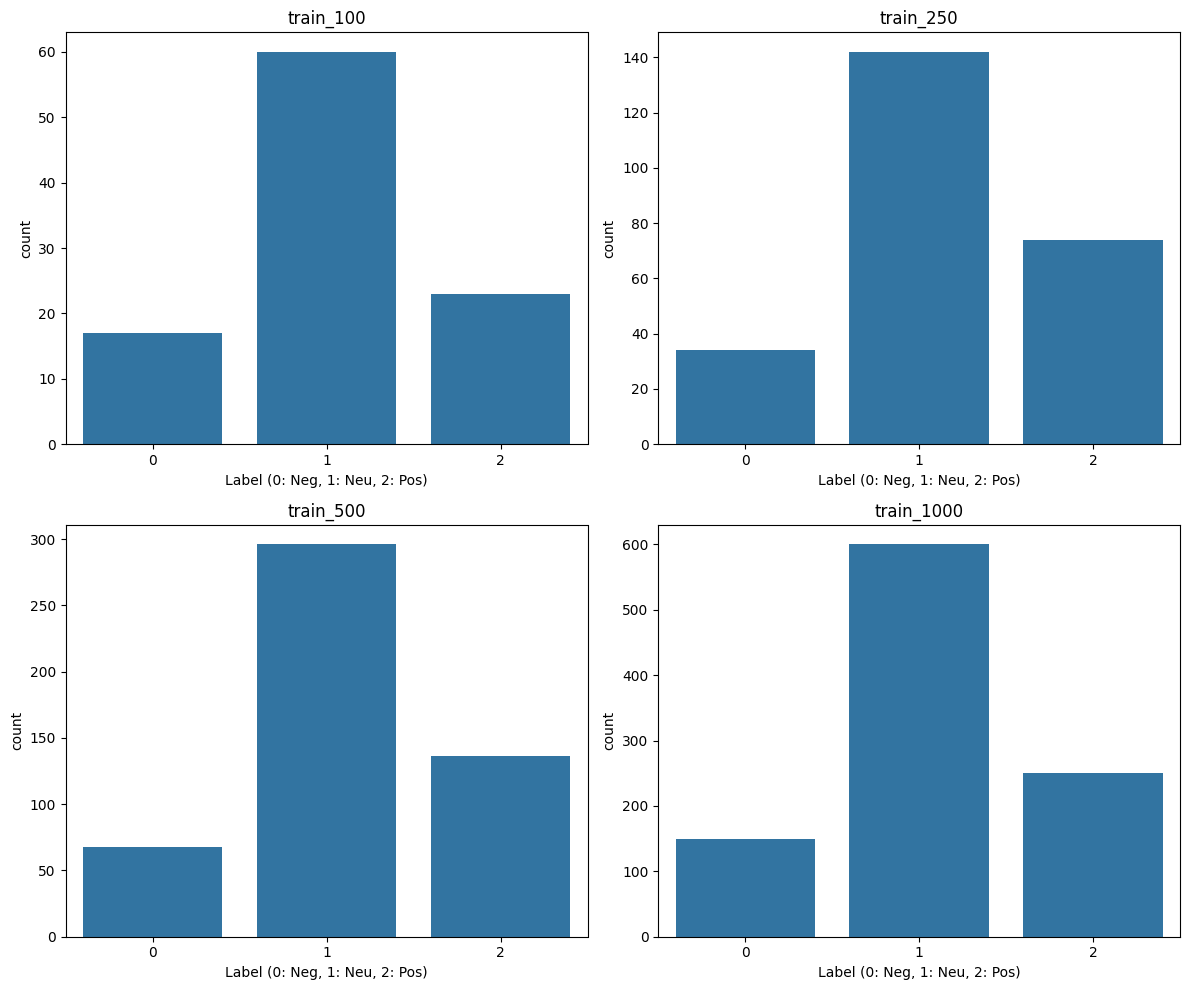

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, size in enumerate(train_sizes):
    train_df = splits[f"train_{size}"]
    sns.countplot(x="label", data=train_df, ax=axes[i])
    axes[i].set_title(f"train_{size}")
    axes[i].set_xlabel("Label (0: Neg, 1: Neu, 2: Pos)")

plt.tight_layout()
plt.show()

## Split Refactor Summary

What changed in this step:
- Data loading is now agreement-aware and loads all four Financial PhraseBank agreement subsets.
- Hard-label training, validation, and the hidden pool now come only from deduplicated 100%-agreement data.
- `test_allagree` and `test_disagree` are frozen separately and can be reused across all later experiments.
- `hidden_allagree_pool` is fixed once and does not shrink as train size increases.

What still needs adaptation next:
- The existing downstream training cells still use `test_df = test_allagree_df` as a temporary compatibility alias.
- Weak-labeling and semi-supervised sections now target the fixed clean hidden pool, but they still need explicit dual-test-set reporting later.
- Embedding and LLM analysis cells still default to `test_df` and should later be extended to compare both test sets.

# Baseline Model Training

This notebook now prepares two reusable classifier baselines for the sentiment task:
- DistilBERT: `distilbert-base-uncased`
- ModernBERT: `answerdotai/ModernBERT-base`

The baseline section below still runs one active backbone at a time so the current notebook flow stays intact.

In [6]:
class WeakLabeler:
    def __init__(self, model_name: str = "all-mpnet-base-v2"):
        self.model = SentenceTransformer(model_name)

    def encode(self, sentences: List[str]) -> np.ndarray:
        return self.model.encode(sentences, show_progress_bar=True)

    def train_knn(
        self, train_df: pd.DataFrame, n_neighbors: int = 5
    ) -> KNeighborsClassifier:
        embeddings = self.encode(train_df["sentence"].tolist())
        labels = train_df["label"].tolist()

        knn = KNeighborsClassifier(n_neighbors=n_neighbors)
        knn.fit(embeddings, labels)
        return knn

    def predict(
        self, knn: KNeighborsClassifier, unlabeled_df: pd.DataFrame
    ) -> pd.DataFrame:
        sentences = unlabeled_df["sentence"].tolist()
        embeddings = self.encode(sentences)

        weak_labels = knn.predict(embeddings)

        result_df = unlabeled_df.copy()
        result_df["label"] = weak_labels
        result_df["is_weak"] = True

        return result_df


## Train and Evaluate on Different Sizes

We train one configurable classifier backbone across the nested hard-label splits and record baseline-ready metrics. The reusable helpers now return accuracy, macro F1, and negative-class precision/recall/F1.

TODOs for the next notebook step:
- Compare DistilBERT vs ModernBERT side by side.
- Report both `test_allagree_df` and `test_disagree_df`.
- Store confusion matrices for later plotting.

In [ ]:
results = []

for size in train_sizes:
    print(f"\n=== Training {BASELINE_MODEL_KEY} on {size} samples ===")
    train_df = splits[f"train_{size}"]

    trained = train_classifier(
        train_df=train_df,
        val_df=val_df,
        model_name=BASELINE_MODEL_NAME,
        output_dir=f"models/{BASELINE_MODEL_KEY}_{size}",
        batch_size=16,
        epochs=3,
        seed=42,
        negative_label=NEGATIVE_LABEL,
        id2label=SENTIMENT_ID2LABEL,
        label2id=SENTIMENT_LABEL2ID,
    )

    # TODO: Evaluate both frozen test sets once the dual-test reporting cell is added.
    # TODO: Add confusion-matrix collection when the notebook adds plotting support.
    metrics = evaluate_classifier(
        model=trained["model"],
        tokenizer=trained["tokenizer"],
        eval_df=test_df,
        negative_label=NEGATIVE_LABEL,
        include_confusion_matrix=False,
    )
    print(f"Results for {size}: {metrics}")

    results.append(
        {
            "train_size": size,
            **metrics,
        }
    )

## Plot Learning Curve

In [ ]:
results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.plot(
    results_df["train_size"],
    results_df["macro_f1"],
    marker="o",
    label="Macro F1",
)
plt.plot(
    results_df["train_size"],
    results_df["negative_f1"],
    marker="^",
    label="Negative F1",
)
plt.plot(
    results_df["train_size"],
    results_df["accuracy"],
    marker="s",
    label="Accuracy",
)
plt.title(f"Learning Curve: {BASELINE_MODEL_KEY} Baseline vs Training Size")
plt.xlabel("Number of Training Samples")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
results_df

,train_size,accuracy,f1
0,100,0.701987,0.428715
1,250,0.761589,0.502521
2,500,0.799117,0.539081
3,1000,0.933775,0.912213


# Weak Labeling

This notebook generates weak labels for the unlabeled data using k-Nearest Neighbors on sentence embeddings.

## Initialize Weak Labeler

We use `all-mpnet-base-v2` for generating embeddings.

In [15]:
labeler = WeakLabeler(model_name="all-mpnet-base-v2")

## Generate and Evaluate Weak Labels

For each split size, we train a k-NN on the labeled set and predict labels for the fixed `hidden_allagree_pool`. We then compare those weak labels with the hidden ground-truth labels retained only for offline evaluation.

In [ ]:
results = []

for size in train_sizes:
    print(f"\n=== Weak Labeling for {size} labeled samples ===")
    train_df = splits[f"train_{size}"]

    # TODO: Later adapt this section to compare alternative weak-label sources explicitly.
    hidden_pool_df = splits["hidden_allagree_pool"]

    # Train k-NN
    knn = labeler.train_knn(train_df, n_neighbors=5)

    # Predict
    weak_labeled_df = labeler.predict(knn, hidden_pool_df)

    # Evaluate against the hidden clean labels that are withheld from training.
    true_labels = hidden_pool_df["label"]
    predicted_labels = weak_labeled_df["label"]

    acc = accuracy_score(true_labels, predicted_labels)
    f1 = f1_score(true_labels, predicted_labels, average="macro")

    print(f"Weak Label Quality (Size {size}): Accuracy={acc:.4f}, F1={f1:.4f}")

    results.append({"train_size": size, "weak_accuracy": acc, "weak_f1": f1})

    # Save weak labeled data for next step (optional, or just re-generate)
    # weak_labeled_df.to_csv(f"data/weak_labeled_{size}.csv", index=False)

## Plot Weak Label Quality

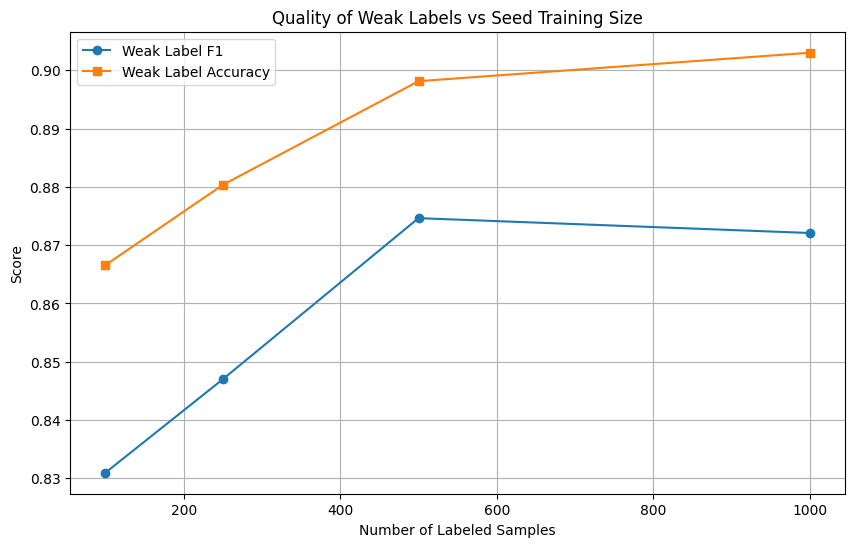

In [ ]:
results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.plot(
    results_df["train_size"], results_df["weak_f1"], marker="o", label="Weak Label F1"
)
plt.plot(
    results_df["train_size"],
    results_df["weak_accuracy"],
    marker="s",
    label="Weak Label Accuracy",
)
plt.title("Quality of Weak Labels vs Seed Training Size")
plt.xlabel("Number of Labeled Samples")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

# Semi-Supervised Training

This notebook trains the sentiment classifier on a combined dataset of hard labels (ground truth) and weak labels (generated by k-NN).

## Train Semi-Supervised Models

For each split size:
1. Train k-NN on labeled data.
2. Generate weak labels for the fixed `hidden_allagree_pool`.
3. Combine labeled and weak-labeled data.
4. Train the currently active baseline backbone.
5. Evaluate on the compatibility alias `test_df` (currently `test_allagree_df`).

TODO: Expand this section later to compare DistilBERT vs ModernBERT explicitly.

In [ ]:
results = []

for size in train_sizes:
    print(f"\n=== Semi-Supervised Training for {size} labeled samples ===")
    train_df = splits[f"train_{size}"]

    # TODO: Later adapt this section to compare alternative weak-label sources explicitly.
    hidden_pool_df = splits["hidden_allagree_pool"]

    # 1. Train k-NN
    knn = labeler.train_knn(train_df, n_neighbors=5)

    # 2. Generate Weak Labels
    weak_labeled_df = labeler.predict(knn, hidden_pool_df)

    # 3. Combine Data
    combined_df = pd.concat(
        [train_df, weak_labeled_df[["sentence", "label"]]]
    ).reset_index(drop=True)
    print(f"Combined training set size: {len(combined_df)}")

    # 4. Train Classifier
    classifier = SentimentClassifier(
        model_name=BASELINE_MODEL_NAME,
        output_dir=f"models/semi_supervised_{BASELINE_MODEL_KEY}_{size}",
        negative_label=NEGATIVE_LABEL,
        id2label=SENTIMENT_ID2LABEL,
        label2id=SENTIMENT_LABEL2ID,
    )
    classifier.train(combined_df, val_df, epochs=3, batch_size=16)

    # 5. Evaluate
    metrics = classifier.evaluate(test_df)
    print(f"Results for {size} (Semi-Supervised): {metrics}")

    results.append(
        {
            "train_size": size,
            "accuracy": metrics["accuracy"],
            "macro_f1": metrics["macro_f1"],
            "negative_f1": metrics["negative_f1"],
        }
    )

## Plot Comparison (Baseline vs Semi-Supervised)

Note: You should manually input the baseline results here or load them from a saved file for comparison.

In [ ]:
results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.plot(
    results_df["train_size"],
    results_df["macro_f1"],
    marker="o",
    label="Semi-Supervised Macro F1",
)
plt.plot(
    results_df["train_size"],
    results_df["negative_f1"],
    marker="^",
    label="Semi-Supervised Negative F1",
)
plt.plot(
    results_df["train_size"],
    results_df["accuracy"],
    marker="s",
    label="Semi-Supervised Accuracy",
)
plt.title(f"Semi-Supervised {BASELINE_MODEL_KEY} Performance vs Training Size")
plt.xlabel("Number of Labeled Samples")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

# Bonus Analysis

This notebook covers the bonus tasks:
1.  **Embedding Visualization**: Using UMAP to visualize sentence embeddings.
2.  **LLM Few-Shot Classification**: Using GPT-4 (or similar) for sentiment analysis via prompting.

## 1. Embedding Visualization (UMAP)

Loading dataset: takala/financial_phrasebank (sentences_allagree)


Using the latest cached version of the dataset since takala/financial_phrasebank couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'sentences_allagree' at /Users/stefanbinkert/.cache/huggingface/datasets/takala___financial_phrasebank/sentences_allagree/1.0.0/550bde12e6c30e2674da973a55f57edde5181d53f5a5a34c1531c53f93b7e141 (last modified on Tue Nov 25 21:04:35 2025).


Total samples: 2264
Test size: 453
Validation size: 182
Training pool size: 1629
Created split 'train_100': 100 samples
Created split 'unlabeled_100': 1529 samples
Created split 'train_250': 250 samples
Created split 'unlabeled_250': 1379 samples
Created split 'train_500': 500 samples
Created split 'unlabeled_500': 1129 samples
Created split 'train_1000': 1000 samples
Created split 'unlabeled_1000': 629 samples


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

/Users/stefanbinkert/Documents/FHNW_DS/NPR/NPR_MC_2/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


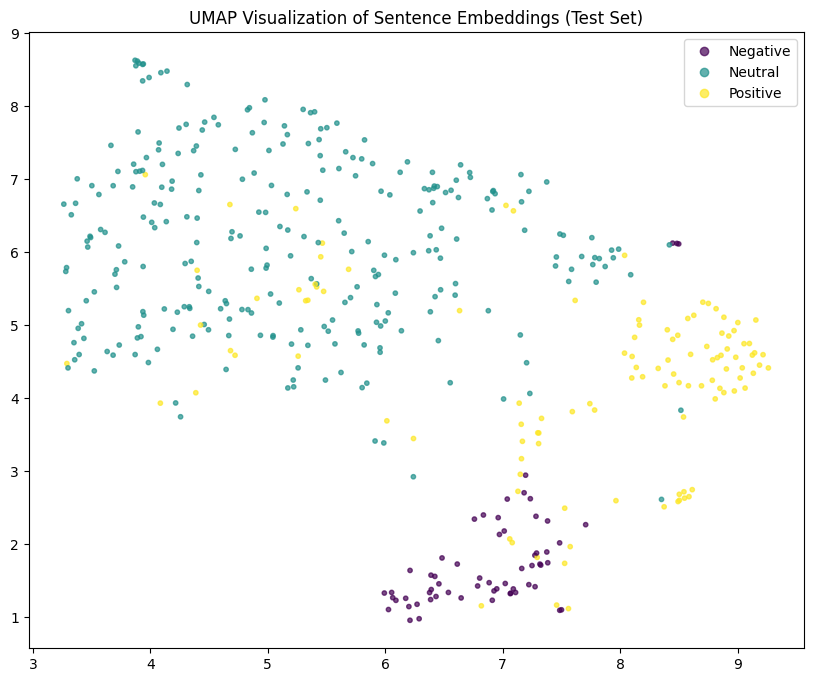

In [22]:
# Generate embeddings for test set
model = SentenceTransformer("all-mpnet-base-v2")
embeddings = model.encode(test_df["sentence"].tolist(), show_progress_bar=True)

# Reduce dimensionality with UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=test_df["label"],
    cmap="viridis",
    s=10,
    alpha=0.7,
)
plt.legend(
    handles=scatter.legend_elements()[0], labels=["Negative", "Neutral", "Positive"]
)
plt.title("UMAP Visualization of Sentence Embeddings (Test Set)")
plt.show()

## 2. LLM Few-Shot Classification

**Note**: This requires an OpenAI API key. Please set `OPENAI_API_KEY` environment variable.

In [23]:
def normalize_llm_label(text):
    cleaned = text.strip().splitlines()[0].strip().strip(".:").lower()
    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    return label_map.get(cleaned)


api_key = os.getenv("OPENAI_API_KEY")

if api_key:
    client = openai.OpenAI(api_key=api_key)
    
    def classify_with_llm(sentence):
        prompt = f"""
        You are a financial sentiment analysis assistant.
        Classify the sentiment of the following financial news sentence as Positive, Negative, or Neutral.
        Provide the label only.
        
        Examples:
        Sentence: "The company's profits surged by 50% this quarter."
        Sentiment: Positive
        
        Sentence: "The CEO resigned amidst a major scandal."
        Sentiment: Negative
        
        Sentence: "The company announced a new product line."
        Sentiment: Neutral
        
        Sentence: "{sentence}"
        Sentiment:
        """
        
        response = client.responses.create(
            model="gpt-5.1",
            reasoning={"effort": "none"},
            input=prompt
        )
        return response.output_text

    # Run on a small subset of test data
    subset_test = test_df.head(20).copy()
    subset_test['llm_pred'] = subset_test['sentence'].apply(classify_with_llm)
    
    subset_test['llm_pred_int'] = subset_test['llm_pred'].apply(normalize_llm_label)
    valid_predictions = subset_test.dropna(subset=['llm_pred_int']).copy()
    
    if valid_predictions.empty:
        print("No valid LLM labels were returned.")
    else:
        acc = accuracy_score(valid_predictions['label'], valid_predictions['llm_pred_int'])
        print(f"LLM Few-Shot Accuracy (on {len(valid_predictions)} valid samples): {acc:.4f}")
    
else:
    print("OPENAI_API_KEY not found. Skipping LLM classification.")

LLM Few-Shot Accuracy (on 20 valid samples): 0.9500
